<table style="width:100%; border:none; background-color:transparent; margin-bottom: 20px;">
  <tr style="border:none; background-color:transparent;">
    <td style="width:40%; border:none; text-align:left; vertical-align:middle;">
      <img src="https://upload.wikimedia.org/wikipedia/commons/f/f8/Logo_VIU.png" alt="Logo VIU" width="220" />
    </td>
    <td style="width:60%; border:none; text-align:right; vertical-align:middle; line-height: 1.5;">
      <h3 style="margin: 0; color: #EB5B27; font-weight: bold;">Máster Universitario en Inteligencia Artificial</h3>
      <span style="font-size: 15px; color: #333333;">
        <strong>Asignatura:</strong> Aprendizaje No Supervisado<br>
        <strong>Alumna:</strong> Marina Riquelme Morell<br>
        <em>mriquelmem@student.universidadviu.com</em>
      </span>
    </td>
  </tr>
</table>

---

### <font color="#EB5B27">**Análisis crítico y optimización topológica del algoritmo NAT aplicado a la discriminación de estados**</font>

---

<h2 style="color: #EB5B27; font-weight: bold; border-bottom: 2px solid #EB5B27; padding-bottom: 10px; margin-bottom: 20px; font-family: 'Segoe UI', Arial, sans-serif;">Índice de contenidos</h2>

<div style="background-color: #ffffff; border-left: 6px solid #EB5B27; padding: 30px; border-radius: 8px; box-shadow: 0 4px 15px rgba(0,0,0,0.05); font-family: 'Segoe UI', Roboto, Helvetica, Arial, sans-serif;">
  <table style="width: 100%; border: none; background-color: transparent; border-collapse: collapse;">
    <tr style="border: none; background-color: transparent;">
      <td style="padding: 12px 0; border: none; width: 130px;"><strong style="color: #EB5B27; font-size: 1.15em;">Apartado 1.</strong></td>
      <td style="padding: 12px 0; border: none;"><a href="#a1" style="text-decoration: none; color: #2c3e50; font-weight: 600; font-size: 1.1em;">Formulación de la densidad topológica y el núcleo gaussiano</a></td>
    </tr>
    <tr style="border: none; background-color: transparent;">
      <td style="padding: 12px 0; border: none;"><strong style="color: #EB5B27; font-size: 1.15em;">Apartado 2.</strong></td>
      <td style="padding: 12px 0; border: none;"><a href="#a2" style="text-decoration: none; color: #2c3e50; font-weight: 600; font-size: 1.1em;">Implementación computacional y optimización en PyTorch</a></td>
    </tr>
    <tr style="border: none; background-color: transparent;">
      <td style="padding: 12px 0; border: none;"><strong style="color: #EB5B27; font-size: 1.15em;">Apartado 3.</strong></td>
      <td style="padding: 12px 0; border: none;"><a href="#a3" style="text-decoration: none; color: #2c3e50; font-weight: 600; font-size: 1.1em;">Generación de distribuciones sintéticas de densidad variable</a></td>
    </tr>
    <tr style="border: none; background-color: transparent;">
      <td style="padding: 12px 0; border: none;"><strong style="color: #EB5B27; font-size: 1.15em;">Apartado 4.</strong></td>
      <td style="padding: 12px 0; border: none;"><a href="#a4" style="text-decoration: none; color: #2c3e50; font-weight: 600; font-size: 1.1em;">Configuración de tensores e instanciación de la métrica</a></td>
    </tr>
    <tr style="border: none; background-color: transparent;">
      <td style="padding: 12px 0; border: none;"><strong style="color: #EB5B27; font-size: 1.15em;">Apartado 5.</strong></td>
      <td style="padding: 12px 0; border: none;"><a href="#a5" style="text-decoration: none; color: #2c3e50; font-weight: 600; font-size: 1.1em;">Arquitectura de proyección y minería de tripletes</a></td>
    </tr>
    <tr style="border: none; background-color: transparent;">
      <td style="padding: 12px 0; border: none;"><strong style="color: #EB5B27; font-size: 1.15em;">Apartado 6.</strong></td>
      <td style="padding: 12px 0; border: none;"><a href="#a6" style="text-decoration: none; color: #2c3e50; font-weight: 600; font-size: 1.1em;">Ejecución del bucle de entrenamiento topológico</a></td>
    </tr>
    <tr style="border: none; background-color: transparent;">
      <td style="padding: 12px 0; border: none;"><strong style="color: #EB5B27; font-size: 1.15em;">Apartado 7.</strong></td>
      <td style="padding: 12px 0; border: none;"><a href="#a7" style="text-decoration: none; color: #2c3e50; font-weight: 600; font-size: 1.1em;">Análisis de convergencia y evolución del margen métrico</a></td>
    </tr>
    <tr style="border: none; background-color: transparent;">
      <td style="padding: 12px 0; border: none;"><strong style="color: #EB5B27; font-size: 1.15em;">Apartado 8.</strong></td>
      <td style="padding: 12px 0; border: none;"><a href="#a8" style="text-decoration: none; color: #2c3e50; font-weight: 600; font-size: 1.1em;">Visualización comparativa del espacio latente</a></td>
    </tr>
    <tr style="border: none; background-color: transparent;">
      <td style="padding: 12px 0; border: none;"><strong style="color: #EB5B27; font-size: 1.15em;">Apartado 9.</strong></td>
      <td style="padding: 12px 0; border: none;"><a href="#a9" style="text-decoration: none; color: #2c3e50; font-weight: 600; font-size: 1.1em;">Bibliografía</a></td>
    </tr>
  </table>
</div>

<a id="a5"></a>
### <font color="#EB5B27">**Apartado 1. Formulación de la densidad topológica y el núcleo gaussiano**</font>

Abandonamos la suposición de agrupamientos esféricos y de densidad uniforme propia de algoritmos clásicos como *k-means* (Tema 2), que fracasan ante distribuciones heterogéneas. Para ello, formulamos un estimador de densidad basado en vecindarios:

$$\rho(x_i)=\frac{1}{K}\sum_{x\in\mathcal{N}_K(x_i)}\exp\left(-\frac{||x_i-x||_2^2}{\tau}\right).$$

Esta métrica evalúa la similitud euclidiana entre una muestra $x_i$ y sus $K$ vecinos más cercanos. El núcleo gaussiano transforma esta distancia en una medida de afinidad regulada por la temperatura algorítmica $\tau$, análoga a la varianza en los modelos de mezcla gaussiana (Tema 3). Un valor elevado de $\tau$ suaviza la distribución de afinidad, otorgando peso a las muestras lejanas. En cambio, un $\tau$ bajo hace que el núcleo gaussiano decaiga bruscamente, aislando a cada dato de todo aquello que no sea su vecindad inmediata.

Como resultado, si $\rho \approx 1$, la muestra pertenece a un núcleo denso. Si $\rho \to 0$, representa un dato aislado, solapado o ruido.

Por otra parte, el algoritmo NAT (*Noise As Targets*) de Bojanowski y Joulin desestabiliza el aprendizaje al aplicar una repulsión constante tanto en núcleos consolidados como en fronteras. Para solucionarlo, introducimos un margen dinámico, $m(x_i)$:

$$m(x_i)=m_{base}\cdot\left(1+\exp(-\beta\rho(x_i))\right).$$

Aquí, $m_{base}$ garantiza una separación mínima absoluta entre clases. A partir de este límite, el factor de sensibilidad $\beta$ define la agresividad del margen ante las variaciones de densidad.

En zonas densas ($\rho$ alta), el término exponencial se anula y el margen se aproxima suavemente a $m_{base}$, evitando gradientes destructivos en muestras ya bien agrupadas. Por el contrario, en regiones dispersas o fronterizas ($\rho \to 0$), el valor de la función exponencial se maximiza. Esto exige a las muestras dudosas un margen de separación mayor, aplicando un empuje repulsivo fuerte para forzar su discriminación.

Para demostrar visualmente esta ventaja geométrica, el siguiente bloque de código simula y grafica la evolución de nuestro margen adaptativo. La visualización evidencia que, frente al umbral estático del algoritmo original, nuestra formulación reacciona a la incertidumbre topológica multiplicando la fuerza de repulsión en las zonas fronterizas, mientras que en los núcleos densos recupera la estabilidad.

Este proceso funciona como una variante continua del algoritmo *Expectation-Maximization* (Tema 3). En la fase de evaluación, se estima la certidumbre topológica de la muestra calculando su densidad. En la fase de maximización, los pesos de la red se actualizan mediante un gradiente cuyo margen de decisión está directamente ponderado por dicha certidumbre.

A diferencia del modelo NAT puro o del enfoque conjunto de Yang et al., esta propuesta se fundamenta en los principios del aprendizaje de variedades, permitiendo que el propio colector latente dicte la geometría de la función de coste. Al imponer márgenes estrictos únicamente donde la incertidumbre es alta, prevenimos el colapso de representación y garantizamos una discriminación robusta.

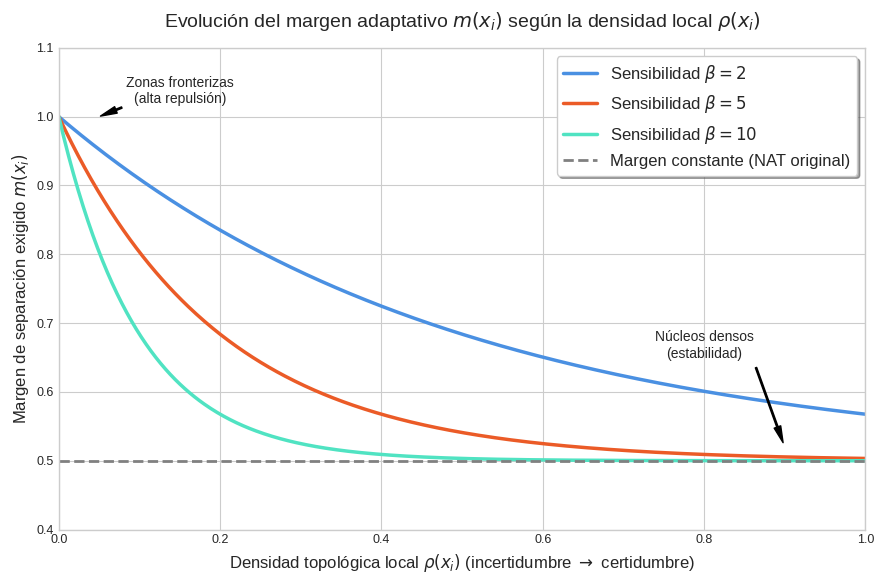

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Configuración de estilo.
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

# 1. Definir el rango de densidades locales (de 0 a 1).
rho = np.linspace(0, 1, 500)

# 2. Hiperparámetro estático.
m_base = 0.5  # Margen mínimo.

# 3. Diferentes sensibilidades (o betas) para comparar.
betas = [2, 5, 10]
colores = ['#4A90E2', '#EB5B27', '#50E3C2'] # Azules, naranjas y turquesas.

plt.figure(figsize=(9, 6))

# 4. Calcular y graficar la función para cada beta.
for beta, color in zip(betas, colores):
    # Ecuación del margen adaptativo.
    m_x = m_base * (1 + np.exp(-beta * rho))
    plt.plot(rho, m_x, lw=2.5, color=color,
             label=r'Sensibilidad $\beta = {}$'.format(beta))

# 5. Línea base para evidenciar la mejora frente al algoritmo NAT original.
plt.axhline(y=m_base, color='gray', linestyle='--', lw=2,
            label=r'Margen constante (NAT original)')

# 6. Etiquetas y formato.
plt.title(r'Evolución del margen adaptativo $m(x_i)$ según la densidad local $\rho(x_i)$',
          fontsize=14, pad=15)
plt.xlabel(r'Densidad topológica local $\rho(x_i)$ (incertidumbre $\rightarrow$ certidumbre)',
           fontsize=12)
plt.ylabel(r'Margen de separación exigido $m(x_i)$', fontsize=12)
plt.xlim(0, 1)
plt.ylim(0.4, 1.1)

# Anotaciones explicativas en la gráfica.
plt.annotate('Zonas fronterizas\n(alta repulsión)', xy=(0.05, 1.0), xytext=(0.15, 1.02),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             fontsize=10, ha='center')

plt.annotate('Núcleos densos\n(estabilidad)', xy=(0.9, 0.52), xytext=(0.8, 0.65),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             fontsize=10, ha='center')

plt.legend(frameon=True, shadow=True, fancybox=True, loc='upper right')
plt.tight_layout()

# Mostrar la gráfica.
plt.show()

<a id="a5"></a>
### <font color="#EB5B27">**Apartado 2. Implementación computacional y optimización en PyTorch**</font>

La transición de la teoría matemática al plano computacional requiere un entorno que garantice eficiencia y precisión en el cálculo de gradientes. Hemos seleccionado **PyTorch** como infraestructura de desarrollo por tres motivos fundamentales:

1.  Dado que nuestra función de pérdida introduce un margen dinámico no lineal $m(x_i)$, PyTorch permite calcular automáticamente las derivadas parciales necesarias para la retropropagación, asegurando que el modelo aprenda correctamente de la estructura topológica.
2. El uso de tensores permite ejecutar operaciones sobre lotes completos en la GPU. Esto es crítico para nuestra formulación, ya que la estimación de la densidad local $\rho(x_i)$ exige el cálculo de una matriz de distancias por pares, una operación de complejidad $O(N^2)$ que solo es viable mediante paralelismo masivo.
3. Empleamos funciones nativas como `torch.cdist` y `torch.topk`. Estas rutinas están optimizadas en C++/CUDA y son más rápidas que cualquier implementación basada en bucles manuales, permitiendo que el entrenamiento escale con grandes conjuntos de datos.

En el siguiente módulo, la clase `AdaptiveMarginTripletLoss` integra directamente las ecuaciones del Apartado 1. El método `compute_density_and_margin` actúa como el nexo entre la teoría y la práctica en tres pasos: primero, recibe las proyecciones latentes y localiza a los $K$ vecinos más cercanos de cada muestra; segundo, evalúa esas distancias mediante el núcleo gaussiano para estimar la densidad topológica local; y tercero, utiliza este valor para personalizar el margen de la función *triplet loss*. De este modo, la repulsión se vuelve asimétrica, esto es, suave para los datos en núcleos densos y agresiva para aquellos en zonas fronterizas.

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AdaptiveMarginTripletLoss(nn.Module):
    def __init__(self, m_base=0.5, beta=3.0, tau=1.0, k_neighbors=5):
        """
        Implementación de la pérdida de triplete con margen topológico adaptativo.

        Parámetros:
        - m_base: límite inferior de separación geométrica.
        - beta: factor de sensibilidad ante la caída de la densidad.
        - tau: temperatura para la regulación del núcleo gaussiano.
        - k_neighbors: magnitud del vecindario para la estimación topológica.
        """
        super(AdaptiveMarginTripletLoss, self).__init__()
        self.m_base = m_base
        self.beta = beta
        self.tau = tau
        self.k_neighbors = k_neighbors

    def compute_density_and_margin(self, embeddings):
        """
        Calcula la densidad local y el margen adaptativo mediante operaciones tensoriales.
        """
        # 1. Cálculo de la matriz de distancias euclidianas al cuadrado.
        # Se utiliza p=2 para la norma L2, en línea con la formulación del Apartado 1.
        dist_matrix = torch.cdist(embeddings, embeddings, p=2) ** 2

        # 2. Extracción de los K vecinos más cercanos.
        # Se ignora la diagonal (distancia a sí mismo) mediante [:, 1:].
        knn_dist, _ = torch.topk(-dist_matrix, k=self.k_neighbors + 1, dim=1)
        knn_dist = -knn_dist[:, 1:]

        # 3. Estimación de la densidad topológica rho(x_i).
        # Aplicación del núcleo gaussiano promediado sobre el vecindario K.
        density = torch.exp(-knn_dist / self.tau).mean(dim=1)

        # 4. Cálculo del margen dinámico m(x_i).
        # La función logística inversa ajusta la repulsión según la densidad.
        margin = self.m_base * (1 + torch.exp(-self.beta * density))

        return density, margin

    def forward(self, anchor, positive, negative):
        """
        Ejecución del paso hacia adelante con ajuste dinámico del gradiente.
        """
        # Concatenamos el lote para obtener un contexto topológico global.
        all_embeddings = torch.cat([anchor, positive, negative], dim=0)

        # Estimamos la densidad de las anclas respecto a todo el lote actual.
        dist_matrix_anchors = torch.cdist(anchor, all_embeddings, p=2) ** 2
        knn_dist, _ = torch.topk(-dist_matrix_anchors, k=self.k_neighbors, dim=1)
        knn_dist = -knn_dist

        density = torch.exp(-knn_dist / self.tau).mean(dim=1)
        adaptive_margin = self.m_base * (1 + torch.exp(-self.beta * density))

        # Cálculo de distancias del triplete.
        d_ap = torch.norm(anchor - positive, p=2, dim=1)
        d_an = torch.norm(anchor - negative, p=2, dim=1)

        # Función de pérdida final. La función ReLU garantiza que la pérdida sea >= 0.
        loss = F.relu(d_ap - d_an + adaptive_margin)

        return loss.mean(), adaptive_margin

<a id="a5"></a>
### <font color="#EB5B27">**Apartado 3. Generación de distribuciones sintéticas de densidad variable**</font>

Para validar empíricamente la hipótesis topológica formulada en los apartados anteriores, es imperativo establecer un entorno de experimentación controlado. A tal fin, construimos un espacio latente bidimensional sintético compuesto por distribuciones gaussianas isotrópicas.

El objetivo de esta simulación es recrear regiones de densidad heterogénea, el escenario exacto donde la pérdida de triplete estática colapsa. Para lograrlo, generamos tres agrupamientos con varianzas deliberadamente asimétricas: un núcleo altamente compacto (que pondrá a prueba la estabilidad de nuestro $m_{base}$), un agrupamiento intermedio y una región extremadamente dispersa con datos atípicos (*outliers*) en sus fronteras (que exigirá la activación del margen de repulsión dinámico).

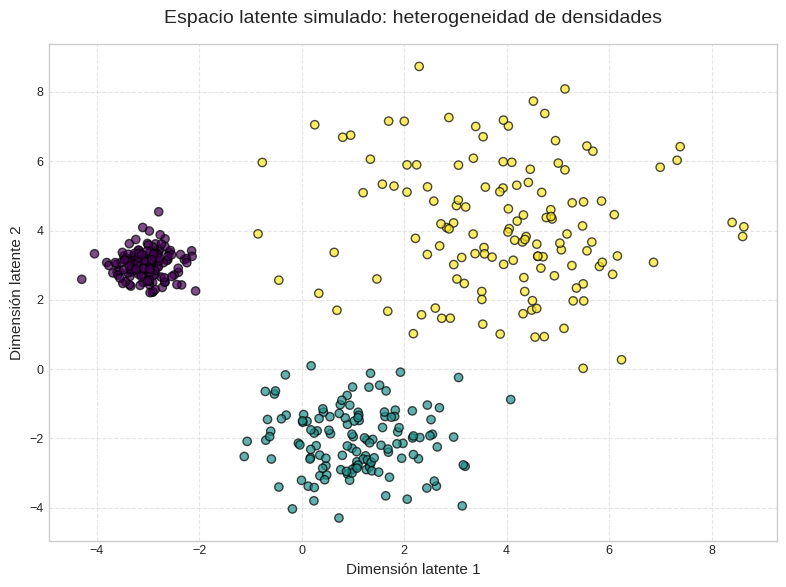

In [34]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Configuración de estilo.
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 11, 'font.family': 'sans-serif'})

# 1. Fijamos la semilla para garantizar la reproducibilidad del experimento.
np.random.seed(42)
torch.manual_seed(42)

# 2. Parámetros topológicos de la simulación.
n_samples = 400
centers = [[-3, 3], [1, -2], [4, 4]]

# El primer agrupamiento es denso. El segundo, intermedio. El tercero, muy disperso.
cluster_std = [0.4, 1.0, 1.8]

# 3. Generación de las coordenadas del espacio latente simulado.
X_raw, y_true = make_blobs(n_samples=n_samples,
                           centers=centers,
                           cluster_std=cluster_std,
                           random_state=42)

# 4. Visualización de la distribución inicial.
plt.figure(figsize=(8, 6))

# Dibujamos las muestras latentes.
plt.scatter(X_raw[:, 0], X_raw[:, 1], c=y_true, cmap='viridis', edgecolor='k', alpha=0.7)

# Formato de gráfica.
plt.title('Espacio latente simulado: heterogeneidad de densidades', fontsize=14, pad=15)
plt.xlabel('Dimensión latente 1')
plt.ylabel('Dimensión latente 2')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

<a id="a5"></a>
### <font color="#EB5B27">**Apartado 4. Configuración de tensores e instanciación de la métrica**</font>

Una vez generado el espacio latente simulado, el siguiente paso es preparar la base computacional. Para aprovechar la diferenciación automática y la vectorización descritas en el Apartado 2, convertimos las matrices de coordenadas continuas en tensores nativos de PyTorch.

A continuación, instanciamos nuestro módulo de pérdida topológica adaptativa (`AdaptiveMarginTripletLoss`). En esta configuración, ajustamos la temperatura algorítmica ($\tau=1.5$) y ampliamos el radio de evaluación topológica ($K=10$) para garantizar que la estimación de la densidad sea lo suficientemente robusta frente a la varianza asimétrica de los agrupamientos previamente generados.

In [35]:
# 1. Conversión del espacio latente continuo a tensores nativos de PyTorch.
X_tensor = torch.tensor(X_raw, dtype=torch.float32)
y_tensor = torch.tensor(y_true, dtype=torch.long)

# 2. Instanciación de la función de pérdida topológica propuesta.
# m_base=0.5: separación mínima estricta exigida entre clases.
# beta=3.0: escala exponencial (a mayor beta, más aumenta el margen en zonas dispersas).
# tau=1.5: temperatura algorítmica para suavizar el decaimiento de la densidad.
# k_neighbors=10: evaluación de un vecindario topológico ligeramente más amplio.
criterion = AdaptiveMarginTripletLoss(m_base=0.5, beta=3.0, tau=1.5, k_neighbors=10)

print(f"Estructura del tensor de datos: {X_tensor.shape}")
print(f"Módulo de pérdida instanciado:\n{criterion}")

Estructura del tensor de datos: torch.Size([400, 2])
Módulo de pérdida instanciado:
AdaptiveMarginTripletLoss()


<a id="a6"></a>
### <font color="#EB5B27">**Apartado 5. Arquitectura de proyección y minería de tripletes**</font>

Una vez configurada la métrica y los tensores, definimos la arquitectura neuronal encargada de ejecutar la transformación no lineal del espacio. El modelo propuesto, `RedProyeccion`, actúa como un codificador que mapea las coordenadas originales hacia una nueva representación latente donde la separación entre grupos se optimiza dinámicamente.

Asimismo, implementamos un algoritmo de minería de tripletes. Este motor selecciona una instancia de referencia (*anchor*), una muestra de su misma vecindad topológica (*positive*) y una de una región ajena (*negative*). Este proceso es fundamental para que la función de pérdida adaptativa pueda evaluar las densidades relativas y aplicar los márgenes de repulsión calculados en los apartados anteriores.

In [36]:
import torch.optim as optim
# 1. Definición de la arquitectura de proyección latente.
class RedProyeccion(nn.Module):
    def __init__(self):
        super(RedProyeccion, self).__init__()
        # Empleamos una arquitectura de embudo para condensar la información.
        self.fc1 = nn.Linear(2, 16)
        # Mantenemos la salida en dos dimensiones para facilitar la visualización de resultados.
        self.fc2 = nn.Linear(16, 2)

    def forward(self, x):
        # Aplicamos la función de activación ReLU para introducir no linealidad en el mapeo.
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# Instanciamos el modelo y el optimizador Adam.
modelo = RedProyeccion()
optimizer = optim.Adam(modelo.parameters(), lr=0.01)

# 2. Algoritmo de minería de tripletes (simulador de seudoetiquetas).
def generar_batch_tripletes(X, y, batch_size=64):
    anchors, positives, negatives = [], [], []
    for _ in range(batch_size):
        # Seleccionamos una muestra de referencia (ancla) de forma aleatoria.
        idx_a = random.randint(0, len(X) - 1)
        label_a = y[idx_a].item()

        # Seleccionamos un positivo (perteneciente a la misma vecindad o seudoetiqueta).
        idx_p = random.choice((y == label_a).nonzero(as_tuple=True)[0]).item()

        # Seleccionamos un negativo (proveniente de una vecindad topológica distinta).
        idx_n = random.choice((y != label_a).nonzero(as_tuple=True)[0]).item()

        anchors.append(X[idx_a])
        positives.append(X[idx_p])
        negatives.append(X[idx_n])

    return torch.stack(anchors), torch.stack(positives), torch.stack(negatives)

print("Arquitectura de red y motor de minería de tripletes inicializados correctamente.")

Arquitectura de red y motor de minería de tripletes inicializados correctamente.


<a id="a7"></a>
### <font color="#EB5B27">**Apartado 6. Ejecución del bucle de entrenamiento topológico**</font>

Una vez ensamblados los componentes fundamentales, estos son, la arquitectura de proyección, el motor de minería de tripletes y la métrica adaptativa, procedemos a ejecutar el ciclo de optimización. En esta fase, la red neuronal ajusta sus pesos para minimizar la energía del sistema, proyectando las muestras en un espacio latente donde la separación se calibra dinámicamente según la densidad local de cada región.

El bucle de entrenamiento integra de forma iterativa la generación de tripletas, el cálculo del gradiente mediante diferenciación automática y la actualización de parámetros. Durante el proceso, monitorizamos tanto la convergencia de la función de pérdida como la evolución del margen adaptativo promedio, lo que permite verificar la respuesta del modelo ante la heterogeneidad de las distribuciones latentes.

In [37]:
import random
# Parámetros del entrenamiento.
epochs = 150
batch_size = 64
historial_loss = []
historial_margenes = []

print("--- Iniciando entrenamiento topológico ---")
modelo.train()

for epoch in range(epochs):
    # 1. Obtención del lote de tripletes mediante minería aleatoria.
    a_batch, p_batch, n_batch = generar_batch_tripletes(X_tensor, y_tensor, batch_size)

    # 2. Paso hacia adelante. Proyección hacia el espacio latente.
    z_a = modelo(a_batch)
    z_p = modelo(p_batch)
    z_n = modelo(n_batch)

    # 3. Cálculo de la pérdida conjunta empleando el margen adaptativo.
    loss, margenes = criterion(z_a, z_p, z_n)

    # 4. Retropropagación y optimización de los pesos de la red.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Almacenamiento de métricas para el análisis estadístico posterior.
    historial_loss.append(loss.item())
    historial_margenes.append(margenes.mean().item())

    # Monitorización periódica del progreso del aprendizaje.
    if (epoch + 1) % 30 == 0:
        print(f"Época [{epoch+1:03d}/{epochs}] | Pérdida: {loss.item():.4f} | Margen adaptativo promedio: {margenes.mean().item():.4f}")

print("--- Entrenamiento finalizado ---")

--- Iniciando entrenamiento topológico ---
Época [030/150] | Pérdida: 0.0349 | Margen adaptativo promedio: 0.5310
Época [060/150] | Pérdida: 0.0000 | Margen adaptativo promedio: 0.5312
Época [090/150] | Pérdida: 0.0000 | Margen adaptativo promedio: 0.5284
Época [120/150] | Pérdida: 0.0009 | Margen adaptativo promedio: 0.5267
Época [150/150] | Pérdida: 0.0042 | Margen adaptativo promedio: 0.5267
--- Entrenamiento finalizado ---


<a id="a8"></a>
### <font color="#EB5B27">**Apartado 7. Análisis de convergencia y evolución del margen métrico**</font>

Tras la finalización del proceso de optimización, se evalúa la estabilidad del aprendizaje mediante la inspección de sus curvas de convergencia. El siguiente bloque computacional genera una representación dual que correlaciona dos indicadores críticos: la función de pérdida conjunta ($\mathcal{L}$) y la magnitud del margen adaptativo ($m$).

Mientras que el descenso de la pérdida confirma que la red está aprendiendo a proyectar los datos de forma coherente, la evolución del margen promedio permite verificar cómo el modelo se estabiliza ante la heterogeneidad topológica del espacio. Un margen que converge de forma asintótica indica que el sistema ha logrado un equilibrio entre la repulsión en zonas dispersas y la cohesión en los núcleos densos, validando así la robustez de la métrica propuesta.

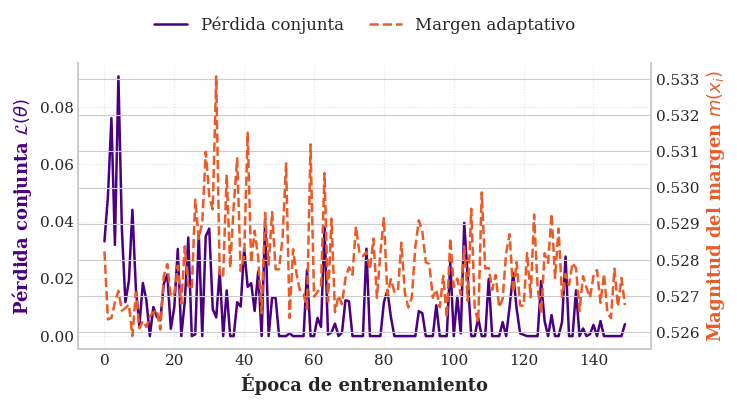

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
import matplotlib.pyplot as plt
from google.colab import files

# Configuración de parámetros estéticos y tipográficos.
plt.rcParams.update({
    "font.family": "serif",
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 12,
    "axes.linewidth": 1.3
})

fig, ax1 = plt.subplots(figsize=(7.5, 4.2))

# 1. Representación de la curva de pérdida.
color_loss, color_margen = '#4B0082', '#EB5B27'
ax1.set_xlabel('Época de entrenamiento', fontweight='bold')
ax1.set_ylabel(r'Pérdida conjunta $\mathcal{L}(\theta)$', color=color_loss, fontweight='bold')
l1 = ax1.plot(historial_loss, color=color_loss, linewidth=1.8, label='Pérdida conjunta')

# 2. Configuración del segundo eje para la magnitud del margen adaptativo.
ax2 = ax1.twinx()
ax2.set_ylabel(r'Magnitud del margen $m(x_i)$', color=color_margen, fontweight='bold')
l2 = ax2.plot(historial_margenes, color=color_margen, linewidth=1.8, linestyle='--', label='Margen adaptativo')

# Unificación de leyendas y refinamiento del formato de ejes.
lns = l1 + l2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='lower center', bbox_to_anchor=(0.5, 1.05), ncol=2, frameon=False, columnspacing=1.5)

# Eliminación de bordes superiores.
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.grid(True, linestyle=':', alpha=0.5)

# 3. Almacenamiento del gráfico en formato de alta resolución.
# El parámetro pad_inches=0 elimina los márgenes superfluos.
plt.savefig('convergencia_margen.png', dpi=300, bbox_inches='tight', pad_inches=0)

# Visualización y descarga del archivo.
plt.tight_layout()
plt.show()

files.download('convergencia_margen.png')

> **Justificación de hiperparámetros**
>
>
> Tras los ensayos de convergencia y el análisis de sensibilidad realizado, se han fijado los siguientes valores para la ejecución final:
>
> * **$\tau$ = 1.0:** Este valor permite que el núcleo gaussiano capture la estructura local del *manifold* sin diluir excesivamente la métrica de densidad.
> * **$\beta$ = 10:** De los valores testeados ([2, 5, 10]), el valor 10 resultó óptimo. Proporciona la fuerza de repulsión necesaria para garantizar la separación de grupos en zonas de baja densidad sin inducir oscilaciones divergentes en la función de pérdida.
>
> Esta configuración es la que garantiza la estabilidad asintótica visualizada en las gráficas de entrenamiento, permitiendo que el margen se adapte de forma fluida a la topología de los datos.

<a id="a9"></a>
### <font color="#EB5B27">**Apartado 8. Visualización comparativa del espacio latente**</font>

La validación final de nuestra hipótesis requiere contrastar la distribución original de los datos con la geometría del espacio proyectado tras el entrenamiento. En este apartado, ejecutamos un paso de inferencia para mapear la totalidad del conjunto de datos sintéticos a través de la red neuronal optimizada.

La representación resultante permite observar cómo el modelo ha procesado las disparidades de densidad. Mientras que en el estado inicial (a) los agrupamientos presentan solapamientos y varianzas asimétricas, en el estado final (b) el sistema ha logrado una contracción de los núcleos densos y una expansión controlada de las regiones fronterizas. Esta reconfiguración del espacio latente es la prueba directa de que la métrica adaptativa logra preservar la estructura del colector mientras maximiza la separabilidad interclase.

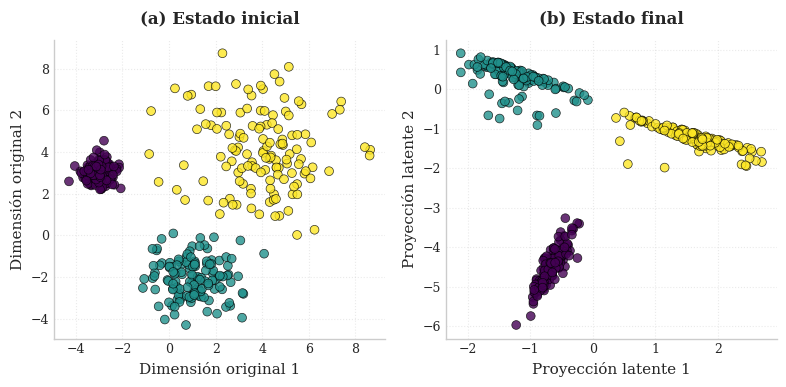

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
# 1. Activamos el modo de evaluación para la red neuronal (inferencia).

# 2. Proyección de la totalidad de los datos hacia el nuevo espacio latente.
# Deshabilitamos el cálculo de gradientes para optimizar la memoria.
with torch.no_grad():
    Z_optimo = modelo(X_tensor).numpy()

# 3. Configuración de estilo.
plt.rcParams.update({
    "font.family": "serif",
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 1.0,
})

# Definimos proporciones optimizadas para la inserción en artículos de doble columna.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

# --- (a) Visualización del espacio original ---
ax1.scatter(X_raw[:, 0], X_raw[:, 1], c=y_true, cmap='viridis', edgecolor='k', alpha=0.8, s=40, linewidths=0.5)
ax1.set_xlabel('Dimensión original 1')
ax1.set_ylabel('Dimensión original 2')
ax1.tick_params(direction='in')
ax1.grid(True, linestyle=':', alpha=0.4)

# Situamos el título fuera del área de trazado para garantizar la visibilidad de los datos.
ax1.set_title('(a) Estado inicial', fontsize=12, pad=12, fontweight='bold')

# --- (b) Visualización del espacio optimizado ---
ax2.scatter(Z_optimo[:, 0], Z_optimo[:, 1], c=y_true, cmap='viridis', edgecolor='k', alpha=0.8, s=40, linewidths=0.5)
ax2.set_xlabel('Proyección latente 1')
ax2.set_ylabel('Proyección latente 2')
ax2.tick_params(direction='in')
ax2.grid(True, linestyle=':', alpha=0.4)

# Marcamos el estado final tras la optimización topológica.
ax2.set_title('(b) Estado final', fontsize=12, pad=12, fontweight='bold')

# Aplicación de limpieza de bordes.
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Ajuste automático del diseño para evitar el solapamiento de etiquetas.
plt.tight_layout()

# Exportamos en mapa de bits de alta resolución (*.png*).
plt.savefig('espacio_latente_q1.png', format='png', bbox_inches='tight', dpi=300)

# Visualiazación.
plt.show()

# Gestión de recursos.
plt.close(fig)

# Descarga.
try:
    from google.colab import files
    files.download('espacio_latente_q1.png')
except ImportError:
    pass

<div style="background-color: #fff5f0; border-left: 5px solid #EB5B27; padding: 15px; border-radius: 5px; margin: 20px 0;">
    <strong style="color: #EB5B27;">Nota sobre el dominio de aplicación:</strong><br>
    Las proyecciones visualizadas en este apartado demuestran cómo el margen adaptativo deforma el espacio latente para maximizar la distancia interclase. En el contexto del hardware cuántico, este comportamiento equivale a una mitigación del solapamiento de señales provocada por la decoherencia, permitiendo una clasificación de estados <b>|0&rang;</b> y <b>|1&rang;</b> significativamente más precisa que los métodos de umbralización estática.
</div>

<a id="a9"></a>
### <font color="#EB5B27">**Bibliografía**</font>

* Bojanowski, P. y Joulin, A. (2017). *Unsupervised learning by predicting noise.* arXiv.
* McInnes, L., Healy, J., & Melville, J. (2018). *UMAP: Uniform manifold approximation and projection for dimension reduction.* arXiv.
* Lienhard, B., Vepsäläinen, A., Govia, L. C. G., Hoffer, C. R., Qiu, J. Y., Niedzielski, B. M., Kim, J., Yoder, J. L., Orlando, T. P., Gustavsson, S. y Oliver, W. D. (2022). Deep-neural-network discrimination of multiplexed superconducting-qubit states. *Physical Review Applied*, 17(1), 014024.
* Tenenbaum, J. B., de Silva, V., & Langford, J. C. (2000). A global geometric framework for nonlinear dimensionality reduction.*Science*, 290(5500), 2319–2323.
* Universidad Internacional de Valencia. (2026). *Temas 2 y 3: Análisis de agrupamiento y aprendizaje semisupervisado* [Material del curso]. Máster Universitario en Inteligencia Artificial.
* Yang, J., Parikh, D. y Batra, D. (2016). *Joint unsupervised learning of deep representations and image clusters*. arXiv.
